In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout

from tensorflow.keras.utils import to_categorical

# Ye asli CNN banane ke building blocks hain — inhi se model architecture banega.

In [2]:
import tensorflow as tf

data_dir = "Cyclone_Wildfire_Flood_Earthquake_Dataset"   # or use the full path: r"C:\Deep_Learning\CNN\flowers"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred", # folder ka naam hi label ban jayega
    image_size=(224, 224), # Har image ko resize kar ke 224x224 pixels ka bana diya jayega
    batch_size=32, # ek baar mai model ko 32 images ka group diya jayega 
    validation_split=0.2, # total data ka 80% training ke liyea rakha jayega aur 20% validation ke liyea
    subset="training", 
    seed=42 #random Splitting hamesha seed ke saath chiyea taki har baar same split mile
)

val_ds = tf.keras.utils.image_dataset_from_directory( # sabkuch same bas remaning 20% validation data ke liyea
    data_dir,
    labels="inferred",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

class_names = train_ds.class_names # Ye folder name ko ek list mai nikaal leta hai
print(class_names)

'''
Important: Ye list ka order hi model ke output se match karega. Yani agar model output index 0 de, to matlab "daisy", index 2 de to matlab "rose" — isi list ke through hum number ko naam mein convert karenge (prediction step mein yahi use hoga).
'''

Found 4428 files belonging to 4 classes.
Using 3543 files for training.
Found 4428 files belonging to 4 classes.
Using 885 files for validation.
['Cyclone', 'Earthquake', 'Flood', 'Wildfire']


'\nImportant: Ye list ka order hi model ke output se match karega. Yani agar model output index 0 de, to matlab "daisy", index 2 de to matlab "rose" — isi list ke through hum number ko naam mein convert karenge (prediction step mein yahi use hoga).\n'

In [3]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [4]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [5]:
val_ds = val_ds.map(lambda x, y: (normalization_layer(x),y))

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

In [8]:
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)


In [9]:
num_classes = len(class_names)
model = Sequential([
    Conv2D(32,(3,3), activation = 'relu', input_shape = (224,224,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

In [10]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']

)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.5357 - loss: 1.1081 - val_accuracy: 0.7367 - val_loss: 0.6981
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7494 - loss: 0.6827 - val_accuracy: 0.7944 - val_loss: 0.5890
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.7846 - loss: 0.5749 - val_accuracy: 0.8000 - val_loss: 0.5255
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8278 - loss: 0.4774 - val_accuracy: 0.8520 - val_loss: 0.4728
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 107s 962ms/step - accuracy: 0.8609 - loss: 0.3690 - val_accuracy: 0.8757 - val_loss: 0.4234
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 97s 872ms/step - accuracy: 0.8843 - loss: 0.3216 - val_accuracy: 0.8508 - val_loss: 0.4746
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 95s 856ms/step - accuracy: 0.9246 - loss: 0.2263 - val_accuracy: 0.8588 - val_loss: 0.5022
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 97s 878ms/step - accuracy: 0.9277 - loss: 0.2034 -

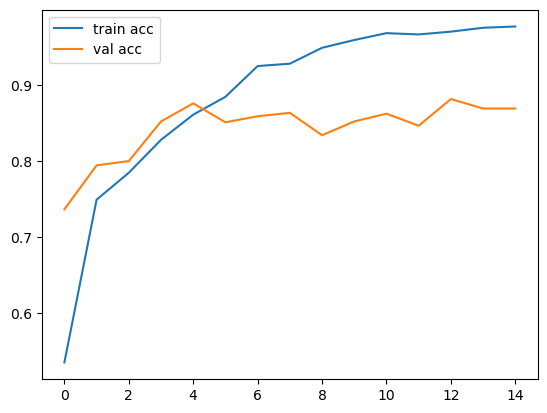

In [12]:
plt.plot(history.history["accuracy"],label = 'train acc')
plt.plot(history.history['val_accuracy'],label = 'val acc')
plt.legend()
plt.show()

In [13]:
img_path = r"C:\Deep_Learning\CNN - Digestar Predection\Cyclone_Wildfire_Flood_Earthquake_Dataset\Flood\30.jpg"
img = tf.keras.utils.load_img(img_path,target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array,0) / 255.0

In [14]:
predection = model.predict(img_array)
predicted_class = class_names[np.argmax(predection)]
confidence = np.max(predection)*100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


In [15]:
print(f"Predicted Digester: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Predicted Digester: Flood
Confidence: 100.00%


In [16]:
model.save("Digester_model.keras")